---
## Section 1 — Setup & Constants

In [ ]:
# Install required packages
!pip install kagglehub -q

In [ ]:
"""
imports.py — All third-party imports for the AE / VAE assignment.
Sources:
  - https://www.tensorflow.org/tutorials/generative/autoencoder
  - https://www.tensorflow.org/tutorials/generative/cvae
"""

import os
import random
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

import kagglehub

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
"""
constants.py — Global hyper-parameters and reproducibility seeds.
All magic numbers are defined here; they are never used inline.
"""

# ── Reproducibility ──────────────────────────────────────────────
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Image properties ─────────────────────────────────────────────
IMG_SIZE: int    = 64        # Medical MNIST images are 64×64
IMG_CHANNELS: int = 1        # Grayscale
IMG_SHAPE: tuple = (IMG_SIZE, IMG_SIZE, IMG_CHANNELS)

# ── tf.data pipeline ─────────────────────────────────────────────
BATCH_SIZE: int   = 128
BUFFER_SIZE: int  = 10_000   # shuffle buffer  (source 2)
VAL_SPLIT: float  = 0.15     # fraction used for validation
TEST_SPLIT: float = 0.10     # fraction used for test

# ── Model architecture ───────────────────────────────────────────
LATENT_DIM_2D: int   = 2     # for visualization (source 2 uses 2)
LATENT_DIM_FULL: int = 16    # richer latent space for better recon

# ── Training ─────────────────────────────────────────────────────
EPOCHS_AE: int   = 20
EPOCHS_VAE: int  = 20
LEARNING_RATE: float = 1e-4  # Adam lr used in source 2

# ── Denoising ────────────────────────────────────────────────────
NOISE_FACTOR: float = 0.2    # source 1 denoising example

# ── Generation ───────────────────────────────────────────────────
NUM_GENERATE: int  = 16      # source 2 uses 16
MANIFOLD_N: int    = 15      # grid size for latent manifold

# ── Class names (Medical MNIST) ──────────────────────────────────
CLASS_NAMES = [
    "AbdomenCT", "BreastMRI", "ChestCT",
    "CXR", "Hand", "HeadCT"
]
NUM_CLASSES: int = len(CLASS_NAMES)

print("Constants loaded. LATENT_DIM_2D =", LATENT_DIM_2D,
      " | LATENT_DIM_FULL =", LATENT_DIM_FULL)

Constants loaded. LATENT_DIM_2D = 2  | LATENT_DIM_FULL = 16


---
## Section 2 — Data Pipeline

We download the Medical MNIST dataset via `kagglehub`, build a `tf.data` pipeline  
with batching, shuffling and normalisation — following the pipeline style of **source 2**.

In [ ]:
# ─── Download dataset ────────────────────────────────────────────
# Source: kagglehub (as specified in the assignment)
path = kagglehub.dataset_download("andrewmvd/medical-mnist")
print("Path to dataset files:", path)
DATASET_ROOT = pathlib.Path(path)

Using Colab cache for faster access to the 'medical-mnist' dataset.
Path to dataset files: /kaggle/input/medical-mnist


In [ ]:
"""
data_pipeline.py
Build tf.data.Dataset from the Medical MNIST folder structure.
Normalisation and pipeline strategy follow source 2 (CVAE tutorial).
"""

def load_and_preprocess_image(file_path: tf.Tensor) -> tf.Tensor:
    """
    Load a single image file, decode, resize and normalise to [0, 1].

    Args:
        file_path: Scalar string tensor pointing to a .jpeg/.png file.

    Returns:
        Float32 tensor of shape (IMG_SIZE, IMG_SIZE, 1) in [0, 1].
    """
    raw = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(raw, channels=IMG_CHANNELS)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0      # normalise — source 2
    return img


def get_label_from_path(file_path: tf.Tensor) -> tf.Tensor:
    """
    Extract integer class label from parent-folder name.

    Args:
        file_path: Scalar string tensor.

    Returns:
        Integer32 scalar label.
    """
    parts  = tf.strings.split(file_path, os.sep)
    label  = tf.where(
        tf.equal(parts[-2], CLASS_NAMES[0]), 0,
    tf.where(
        tf.equal(parts[-2], CLASS_NAMES[1]), 1,
    tf.where(
        tf.equal(parts[-2], CLASS_NAMES[2]), 2,
    tf.where(
        tf.equal(parts[-2], CLASS_NAMES[3]), 3,
    tf.where(
        tf.equal(parts[-2], CLASS_NAMES[4]), 4,
        5)))))
    return tf.cast(label, tf.int32)


def build_datasets(
    dataset_root: pathlib.Path,
    batch_size:   int   = BATCH_SIZE,
    buffer_size:  int   = BUFFER_SIZE,
    val_split:    float = VAL_SPLIT,
    test_split:   float = TEST_SPLIT,
) -> tuple:
    """
    Build (train_ds, val_ds, test_ds, label_ds) tf.data.Dataset objects.

    - train_ds   : shuffled, batched, prefetched — images only (for AE/VAE)
    - val_ds     : batched, prefetched — images only
    - test_ds    : batched, prefetched — images only
    - label_ds   : test images paired with integer labels (for latent-space plot)

    Pipeline follows tf.data style from source 2.
    """
    # Collect all image paths
    all_paths = sorted(
        str(p) for p in dataset_root.glob("**/*.jpeg")
    )
    if not all_paths:
        all_paths = sorted(
            str(p) for p in dataset_root.glob("**/*.png")
        )

    n_total = len(all_paths)
    print(f"Total images found: {n_total}")

    # Shuffle paths for split reproducibility
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(n_total)
    all_paths = [all_paths[i] for i in idx]

    n_test  = int(n_total * test_split)
    n_val   = int(n_total * val_split)
    n_train = n_total - n_val - n_test

    train_paths = all_paths[:n_train]
    val_paths   = all_paths[n_train: n_train + n_val]
    test_paths  = all_paths[n_train + n_val:]

    print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

    AUTOTUNE = tf.data.AUTOTUNE

    def _img_only(path: tf.Tensor) -> tf.Tensor:
        return load_and_preprocess_image(path)

    def _img_and_label(path: tf.Tensor) -> tuple:
        return load_and_preprocess_image(path), get_label_from_path(path)

    # ── Train ──
    train_ds = (
        tf.data.Dataset.from_tensor_slices(train_paths)   # source 2 style
        .shuffle(buffer_size, seed=SEED)
        .map(_img_only, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    # ── Validation ──
    val_ds = (
        tf.data.Dataset.from_tensor_slices(val_paths)
        .map(_img_only, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    # ── Test (images only) ──
    test_ds = (
        tf.data.Dataset.from_tensor_slices(test_paths)
        .map(_img_only, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    # ── Test with labels (for latent scatter plot) ──
    label_ds = (
        tf.data.Dataset.from_tensor_slices(test_paths)
        .map(_img_and_label, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    return train_ds, val_ds, test_ds, label_ds


train_ds, val_ds, test_ds, label_ds = build_datasets(DATASET_ROOT)
print("tf.data pipelines ready.")

Total images found: 58954
Train: 44216 | Val: 8843 | Test: 5895
tf.data pipelines ready.


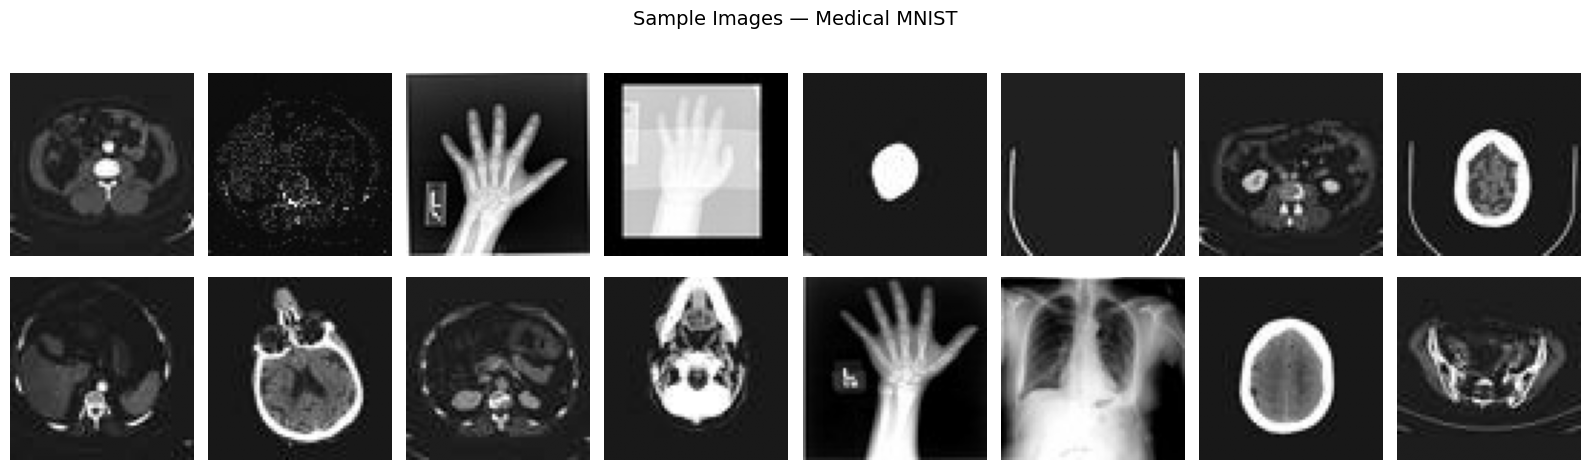

In [ ]:
"""
Visualise sample images from the training set.
Display grid follows source 1 plotting conventions.
"""

sample_batch = next(iter(train_ds))          # first batch
sample_images = sample_batch[:16].numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Sample Images — Medical MNIST", fontsize=14)
for ax, img in zip(axes.flat, sample_images):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Section 3 — Autoencoder (AE)

Architecture from **source 1** (`Denoise` convolutional autoencoder)  
adapted with separate `Encoder` / `Decoder` subclasses and a bottleneck  
Dense layer for latent-space access.

In [ ]:
"""
models/autoencoder.py
Convolutional Autoencoder built from source 1 architecture.
Encoder and Decoder are defined as separate tf.keras.Model subclasses
for modularity, then composed inside the top-level AE class.
"""


class AEEncoder(Model):
    """
    Convolutional encoder that maps an image to a flat latent vector.

    Architecture mirrors source 1 (Denoise model encoder):
        Conv2D(32, 3, strides=2) → Conv2D(64, 3, strides=2) →
        Conv2D(128, 3, strides=2) → Flatten → Dense(latent_dim)

    Args:
        latent_dim: Dimensionality of the bottleneck latent space.
    """

    def __init__(self, latent_dim: int) -> None:
        super(AEEncoder, self).__init__()
        self.latent_dim = latent_dim
        self.conv_stack = tf.keras.Sequential([
            layers.Input(shape=IMG_SHAPE),
            # source 1: Conv2D layers with strides for downsampling
            layers.Conv2D(32,  kernel_size=3, strides=2,
                          activation="relu", padding="same"),
            layers.Conv2D(64,  kernel_size=3, strides=2,
                          activation="relu", padding="same"),
            layers.Conv2D(128, kernel_size=3, strides=2,
                          activation="relu", padding="same"),
            layers.Flatten(),
            layers.Dense(latent_dim, activation="relu"),
        ], name="ae_encoder_stack")

    def call(self, x: tf.Tensor) -> tf.Tensor:
        """
        Forward pass.

        Args:
            x: Batch of images, shape (B, H, W, C).

        Returns:
            Latent vectors, shape (B, latent_dim).
        """
        return self.conv_stack(x)


class AEDecoder(Model):
    """
    Convolutional decoder that reconstructs an image from a latent vector.

    Architecture mirrors source 1 (Denoise model decoder):
        Dense → Reshape → Conv2DTranspose × 3 → Conv2D(1, sigmoid)

    Args:
        latent_dim: Dimensionality of the input latent vector.
    """

    def __init__(self, latent_dim: int) -> None:
        super(AEDecoder, self).__init__()
        # Spatial size after 3 stride-2 convolutions on 64×64 input = 8×8
        self._spatial: int = 8
        self._base_filters: int = 128
        self.deconv_stack = tf.keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(self._spatial * self._spatial * self._base_filters,
                         activation="relu"),
            layers.Reshape((self._spatial, self._spatial, self._base_filters)),
            # source 1: Conv2DTranspose for upsampling
            layers.Conv2DTranspose(128, kernel_size=3, strides=2,
                                   activation="relu", padding="same"),
            layers.Conv2DTranspose(64,  kernel_size=3, strides=2,
                                   activation="relu", padding="same"),
            layers.Conv2DTranspose(32,  kernel_size=3, strides=2,
                                   activation="relu", padding="same"),
            # source 1: final Conv2D with sigmoid — output in [0,1]
            layers.Conv2D(IMG_CHANNELS, kernel_size=3,
                          activation="sigmoid", padding="same"),
        ], name="ae_decoder_stack")

    def call(self, z: tf.Tensor) -> tf.Tensor:
        """
        Forward pass.

        Args:
            z: Latent vectors, shape (B, latent_dim).

        Returns:
            Reconstructed images, shape (B, H, W, C).
        """
        return self.deconv_stack(z)


class AE(Model):
    """
    Full Autoencoder: Encoder + Decoder.

    Composed following the tf.keras.Model subclassing pattern from source 1.
    Exposes `encoder` and `decoder` as public attributes for direct access
    (required for latent-space analysis).

    Args:
        latent_dim: Bottleneck latent-space dimension.
    """

    def __init__(self, latent_dim: int = LATENT_DIM_2D) -> None:
        super(AE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder    = AEEncoder(latent_dim)
        self.decoder    = AEDecoder(latent_dim)

    def call(self, x: tf.Tensor) -> tf.Tensor:
        """
        Full encode → decode forward pass.

        Args:
            x: Input images, shape (B, H, W, C).

        Returns:
            Reconstructed images, same shape as input.
        """
        z = self.encoder(x)
        return self.decoder(z)


# ── Quick sanity check ───────────────────────────────────────────
ae_2d   = AE(latent_dim=LATENT_DIM_2D)
ae_full = AE(latent_dim=LATENT_DIM_FULL)

dummy = tf.zeros((1, IMG_SIZE, IMG_SIZE, IMG_CHANNELS))
out   = ae_2d(dummy)
print("AE (2-D latent) output shape:",   out.shape)
out   = ae_full(dummy)
print("AE (full latent) output shape:", out.shape)

AE (2-D latent) output shape: (1, 64, 64, 1)
AE (full latent) output shape: (1, 64, 64, 1)


---
## Section 4 — Variational Autoencoder (VAE)

Architecture, reparameterisation trick, loss function and `@tf.function`-decorated  
`train_step` all taken directly from **source 2** (CVAE tutorial).

In [ ]:
"""
models/vae.py
Convolutional VAE adapted directly from source 2 (TF CVAE tutorial).
Separate VAEEncoder / VAEDecoder classes for modularity.
"""


class VAEEncoder(Model):
    """
    Probabilistic encoder: maps image → (z_mean, z_log_var).

    Following source 2:
        Conv2D(32) → Conv2D(64) → Flatten → Dense(latent_dim * 2)
    The final Dense layer outputs mean and log-variance concatenated;
    they are split with tf.split inside `encode()`.

    Args:
        latent_dim: Dimension of the latent distribution.
    """

    def __init__(self, latent_dim: int) -> None:
        super(VAEEncoder, self).__init__()
        self.latent_dim = latent_dim
        # source 2: encoder Sequential exactly as in CVAE
        self.conv_stack = tf.keras.Sequential([
            layers.InputLayer(input_shape=IMG_SHAPE),
            layers.Conv2D(32, kernel_size=3, strides=2, activation="relu"),
            layers.Conv2D(64, kernel_size=3, strides=2, activation="relu"),
            layers.Flatten(),
            # No activation — source 2
            layers.Dense(latent_dim + latent_dim),
        ], name="vae_encoder_stack")

    def call(self, x: tf.Tensor) -> tf.Tensor:
        """
        Returns concatenated (z_mean, z_log_var) tensor.
        Use VAE.encode() for the split version.
        """
        return self.conv_stack(x)


class VAEDecoder(Model):
    """
    Decoder: maps a latent sample z → reconstructed image logits.

    Following source 2:
        Dense(spatial*spatial*32) → Reshape → Conv2DTranspose × 2 →
        Conv2DTranspose(output, no activation)

    Args:
        latent_dim: Dimension of the input latent vector.
    """

    def __init__(self, latent_dim: int) -> None:
        super(VAEDecoder, self).__init__()
        # For 64×64 input with two stride-2 convolutions: spatial = 15
        # Use 16 to allow easy reshape, then crop — simpler: compute:
        # 64 / 2 / 2 = 16
        self._spatial: int = 16
        # source 2: decoder Sequential
        self.deconv_stack = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(self._spatial * self._spatial * 32, activation="relu"),
            layers.Reshape((self._spatial, self._spatial, 32)),
            layers.Conv2DTranspose(64, kernel_size=3, strides=2,
                                   padding="same", activation="relu"),
            layers.Conv2DTranspose(32, kernel_size=3, strides=2,
                                   padding="same", activation="relu"),
            # No activation on last layer — source 2
            layers.Conv2DTranspose(IMG_CHANNELS, kernel_size=3,
                                   strides=1, padding="same"),
        ], name="vae_decoder_stack")

    def call(self, z: tf.Tensor) -> tf.Tensor:
        """Returns raw logits (no sigmoid). Apply sigmoid for pixel probs."""
        return self.deconv_stack(z)


class VAE(Model):
    """
    Convolutional Variational Autoencoder.

    Implements the full CVAE from source 2, including:
    - Probabilistic encoder → (z_mean, z_log_var)
    - Reparameterisation trick   (source 2)
    - Monte-Carlo ELBO loss      (source 2)
    - @tf.function train_step    (source 2)

    Args:
        latent_dim: Dimension of the latent Gaussian.
    """

    def __init__(self, latent_dim: int = LATENT_DIM_2D) -> None:
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder    = VAEEncoder(latent_dim)
        self.decoder    = VAEDecoder(latent_dim)

    # ── Source 2: encode / reparameterize / decode ───────────────

    def encode(self, x: tf.Tensor) -> tuple:
        """
        Encode input to (z_mean, z_log_var).

        Args:
            x: Images, shape (B, H, W, C).

        Returns:
            Tuple of (mean, log_var), each shape (B, latent_dim).
        """
        mean, logvar = tf.split(
            self.encoder(x), num_or_size_splits=2, axis=1
        )
        return mean, logvar

    def reparameterize(self, mean: tf.Tensor, logvar: tf.Tensor) -> tf.Tensor:
        """
        Reparameterisation trick: z = mean + eps * exp(0.5 * logvar).
        Taken verbatim from source 2.

        Args:
            mean:   Mean of the latent Gaussian, shape (B, latent_dim).
            logvar: Log-variance,               shape (B, latent_dim).

        Returns:
            Sampled latent vector z, shape (B, latent_dim).
        """
        eps = tf.random.normal(shape=mean.shape)          # source 2
        return eps * tf.exp(logvar * 0.5) + mean           # source 2

    def decode(self,
               z: tf.Tensor,
               apply_sigmoid: bool = False) -> tf.Tensor:
        """
        Decode latent vector to image.

        Args:
            z:              Latent vectors, shape (B, latent_dim).
            apply_sigmoid:  If True, apply sigmoid to get pixel probabilities.

        Returns:
            Logits or probabilities, shape (B, H, W, C).
        """
        logits = self.decoder(z)                          # source 2
        if apply_sigmoid:
            return tf.sigmoid(logits)                     # source 2
        return logits

    @tf.function
    def sample(self, eps: tf.Tensor = None) -> tf.Tensor:
        """
        Sample images from the prior N(0, I). Decorated with @tf.function.
        Source 2 CVAE.sample().

        Args:
            eps: Optional pre-sampled noise. If None, drawn from N(0,I).

        Returns:
            Generated images as sigmoid probabilities.
        """
        if eps is None:
            eps = tf.random.normal(shape=(NUM_GENERATE, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

    def call(self, x: tf.Tensor) -> tf.Tensor:
        """
        Encode then decode (for .fit() compatibility).
        Returns reconstructed images as probabilities.
        """
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        return self.decode(z, apply_sigmoid=True)


# ── Sanity check ─────────────────────────────────────────────────
vae_2d   = VAE(latent_dim=LATENT_DIM_2D)
vae_full = VAE(latent_dim=LATENT_DIM_FULL)

dummy = tf.zeros((1, IMG_SIZE, IMG_SIZE, IMG_CHANNELS))
m, lv = vae_2d.encode(dummy)
z     = vae_2d.reparameterize(m, lv)
out   = vae_2d.decode(z, apply_sigmoid=True)
print("VAE (2-D latent): mean shape", m.shape, " decoded shape", out.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


VAE (2-D latent): mean shape (1, 2)  decoded shape (1, 64, 64, 1)


---
## Section 5 — Training & Loss Visualization

In [ ]:
"""
training/vae_loss.py
Loss functions and train_step taken directly from source 2.
"""


def log_normal_pdf(
    sample: tf.Tensor,
    mean:   tf.Tensor,
    logvar: tf.Tensor,
    raxis:  int = 1
) -> tf.Tensor:
    """
    Log probability of `sample` under N(mean, exp(logvar)).
    Taken verbatim from source 2.

    Args:
        sample: Latent sample z.
        mean:   Distribution mean.
        logvar: Log-variance.
        raxis:  Reduction axis.

    Returns:
        Scalar log-probability per sample.
    """
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2.0 * tf.exp(-logvar) + logvar + log2pi),
        axis=raxis,
    )


def compute_vae_loss(model: VAE, x: tf.Tensor) -> tuple:
    """
    Monte-Carlo ELBO loss from source 2, extended to return both
    total loss and KL divergence for separate tracking.

    Loss = -(E[log p(x|z)] + log p(z) - log q(z|x))
         = reconstruction_loss + kl_loss

    Args:
        model: VAE instance.
        x:     Batch of input images.

    Returns:
        (total_loss, reconstruction_loss, kl_loss) — all scalar tensors.
    """
    mean, logvar = model.encode(x)
    z            = model.reparameterize(mean, logvar)
    x_logit      = model.decode(z)                  # raw logits — source 2

    # Reconstruction loss: binary cross-entropy — source 2
    cross_ent    = tf.nn.sigmoid_cross_entropy_with_logits(
        logits=x_logit, labels=x
    )
    logpx_z      = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])  # source 2

    # KL divergence (via log-normal pdf) — source 2
    logpz        = log_normal_pdf(z, 0.0, 0.0)                # source 2
    logqz_x      = log_normal_pdf(z, mean, logvar)            # source 2
    kl_loss      = tf.reduce_mean(logqz_x - logpz)

    total_loss   = -tf.reduce_mean(logpx_z + logpz - logqz_x) # source 2
    recon_loss   = -tf.reduce_mean(logpx_z)

    return total_loss, recon_loss, kl_loss


@tf.function
def vae_train_step(
    model:     VAE,
    x:         tf.Tensor,
    optimizer: tf.keras.optimizers.Optimizer,
) -> tuple:
    """
    Single VAE training step decorated with @tf.function. Source 2.

    Args:
        model:     VAE instance.
        x:         Batch of images.
        optimizer: Keras optimizer.

    Returns:
        (total_loss, recon_loss, kl_loss) scalars.
    """
    with tf.GradientTape() as tape:
        total_loss, recon_loss, kl_loss = compute_vae_loss(model, x)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, recon_loss, kl_loss


print("VAE loss functions and train_step defined")

VAE loss functions and train_step defined


In [ ]:
"""
training/train_ae.py  — FIXED
Map datasets to (x, x) tuples so Keras .fit() receives explicit
(input, target) pairs, matching Source 1: fit(x_train, x_train, ...).
"""

ae_optimizer_2d   = tf.keras.optimizers.Adam(LEARNING_RATE)
ae_optimizer_full = tf.keras.optimizers.Adam(LEARNING_RATE)

# source 1: compile with MSE
ae_2d.compile(
    optimizer=ae_optimizer_2d,
    loss=losses.MeanSquaredError()
)
ae_full.compile(
    optimizer=ae_optimizer_full,
    loss=losses.MeanSquaredError()
)

# ── Fix: map to (x, x) tuples so Keras has explicit input + target ──
# This mirrors Source 1: autoencoder.fit(x_train, x_train, ...)
def make_autoencoder_dataset(ds: tf.data.Dataset) -> tf.data.Dataset:
    """
    Transform a dataset that yields images into one that yields (img, img)
    pairs, matching Source 1's fit(x_train, x_train, ...) pattern.

    Args:
        ds: tf.data.Dataset yielding image batches of shape (B, H, W, C).

    Returns:
        tf.data.Dataset yielding ((B,H,W,C), (B,H,W,C)) tuple pairs.
    """
    return ds.map(lambda x: (x, x), num_parallel_calls=tf.data.AUTOTUNE)


train_ds_ae = make_autoencoder_dataset(train_ds)
val_ds_ae   = make_autoencoder_dataset(val_ds)

print("Training AE (2-D latent) …")
hist_ae_2d = ae_2d.fit(
    train_ds_ae,
    epochs=EPOCHS_AE,
    validation_data=val_ds_ae,
    verbose=1,
)

print("\nTraining AE (full latent) …")
hist_ae_full = ae_full.fit(
    train_ds_ae,
    epochs=EPOCHS_AE,
    validation_data=val_ds_ae,
    verbose=1,
)

Training AE (2-D latent) …
Epoch 1/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 143s 391ms/step - loss: 0.0561 - val_loss: 0.0269
Epoch 2/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - loss: 0.0259 - val_loss: 0.0250
Epoch 3/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - loss: 0.0249 - val_loss: 0.0244
Epoch 4/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - loss: 0.0242 - val_loss: 0.0237
Epoch 5/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.0237 - val_loss: 0.0235
Epoch 6/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.0233 - val_loss: 0.0230
Epoch 7/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - loss: 0.0230 - val_loss: 0.0227
Epoch 8/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - loss: 0.0227 - val_loss: 0.0226
Epoch 9/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - loss: 0.0225 - val_loss: 0.0223
Epoch 10/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.0223 - val_loss: 0.0221
Epoch 11/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 0.0222 - val_loss: 0.0219
E

In [ ]:
"""
training/train_vae.py — FIXED
The @tf.function trace is model-specific. Build each model before
the training loop so optimizer slot variables are created outside
the tf.function trace, following the TF guide on tf.Variables in
tf.function: https://www.tensorflow.org/guide/function#creating_tfvariables
"""

import time


def train_vae(
    model:     VAE,
    train_ds:  tf.data.Dataset,
    val_ds:    tf.data.Dataset,
    epochs:    int,
    optimizer: tf.keras.optimizers.Optimizer,
) -> dict:
    """
    Full VAE training loop following source 2.

    The train_step is compiled fresh per call via tf.function(...)
    so each (model, optimizer) pair gets its own trace and the
    optimizer slots are initialised outside the function graph.

    Args:
        model:     VAE to train.
        train_ds:  Training tf.data.Dataset.
        val_ds:    Validation tf.data.Dataset.
        epochs:    Number of training epochs.
        optimizer: Keras optimizer instance (must be unused / freshly built).

    Returns:
        History dict with keys 'loss', 'recon_loss', 'kl_loss',
        'val_loss', 'val_recon_loss', 'val_kl_loss'.
    """
    # ── Warm-up: run one forward pass so all Variables exist ────────
    # This forces Keras to build the model weights AND lets the
    # optimizer initialise its slot variables BEFORE tf.function
    # traces the step — exactly the pattern the TF guide recommends.
    dummy = next(iter(train_ds))
    _ = model(dummy)                         # build model variables
    with tf.GradientTape() as tape:
        loss_val, _, _ = compute_vae_loss(model, dummy)
    grads = tape.gradient(loss_val, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    # Now all optimizer slot variables exist — safe to wrap in tf.function

    # ── Compile a fresh tf.function for this (model, optimizer) pair ─
    # We define the step inline so the closure captures the specific
    # model and optimizer objects, matching source 2's train_step pattern.
    def _step(x: tf.Tensor) -> tuple:
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = compute_vae_loss(model, x)
        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return total_loss, recon_loss, kl_loss

    # Compile once after warm-up — no singleton Variable creation inside
    compiled_step = tf.function(_step)     # source 2: @tf.function

    history = {
        "loss": [], "recon_loss": [], "kl_loss": [],
        "val_loss": [], "val_recon_loss": [], "val_kl_loss": [],
    }

    for epoch in range(1, epochs + 1):
        start = time.time()

        # ── Training pass ─────────────────────────────────────────
        train_mean = tf.keras.metrics.Mean()
        recon_mean = tf.keras.metrics.Mean()
        kl_mean    = tf.keras.metrics.Mean()

        for batch in train_ds:
            tot, rec, kl = compiled_step(batch)
            train_mean(tot)
            recon_mean(rec)
            kl_mean(kl)

        # ── Validation pass ───────────────────────────────────────
        val_mean = tf.keras.metrics.Mean()
        val_r_m  = tf.keras.metrics.Mean()
        val_k_m  = tf.keras.metrics.Mean()

        for batch in val_ds:
            tot, rec, kl = compute_vae_loss(model, batch)
            val_mean(tot)
            val_r_m(rec)
            val_k_m(kl)

        history["loss"].append(float(train_mean.result()))
        history["recon_loss"].append(float(recon_mean.result()))
        history["kl_loss"].append(float(kl_mean.result()))
        history["val_loss"].append(float(val_mean.result()))
        history["val_recon_loss"].append(float(val_r_m.result()))
        history["val_kl_loss"].append(float(val_k_m.result()))

        elapsed = time.time() - start
        print(
            f"Epoch {epoch:02d}/{epochs} "
            f"| loss={history['loss'][-1]:.2f} "
            f"| recon={history['recon_loss'][-1]:.2f} "
            f"| kl={history['kl_loss'][-1]:.2f} "
            f"| val_loss={history['val_loss'][-1]:.2f} "
            f"({elapsed:.1f}s)"
        )

    return history


# ── Re-instantiate vae_full optimizer (the old one is already used) ─
vae_optimizer_2d   = tf.keras.optimizers.Adam(LEARNING_RATE)
vae_optimizer_full = tf.keras.optimizers.Adam(LEARNING_RATE)

print("Training VAE (2-D latent) …")
hist_vae_2d = train_vae(
    vae_2d, train_ds, val_ds, EPOCHS_VAE, vae_optimizer_2d
)

print("\nTraining VAE (full latent) …")
hist_vae_full = train_vae(
    vae_full, train_ds, val_ds, EPOCHS_VAE, vae_optimizer_full
)

Training VAE (2-D latent) …
Epoch 01/20 | loss=2072.06 | recon=2064.78 | kl=7.28 | val_loss=2075.49 (19.7s)
Epoch 02/20 | loss=2070.91 | recon=2063.60 | kl=7.31 | val_loss=2075.16 (20.0s)
Epoch 03/20 | loss=2070.07 | recon=2062.74 | kl=7.33 | val_loss=2073.94 (18.7s)
Epoch 04/20 | loss=2069.37 | recon=2062.01 | kl=7.35 | val_loss=2072.52 (20.2s)
Epoch 05/20 | loss=2068.31 | recon=2060.94 | kl=7.38 | val_loss=2071.92 (21.6s)
Epoch 06/20 | loss=2067.48 | recon=2060.08 | kl=7.40 | val_loss=2071.76 (18.3s)
Epoch 07/20 | loss=2066.65 | recon=2059.23 | kl=7.42 | val_loss=2071.13 (25.6s)
Epoch 08/20 | loss=2065.69 | recon=2058.28 | kl=7.41 | val_loss=2070.07 (17.7s)
Epoch 09/20 | loss=2065.91 | recon=2058.48 | kl=7.43 | val_loss=2069.15 (19.7s)
Epoch 10/20 | loss=2065.01 | recon=2057.59 | kl=7.43 | val_loss=2068.68 (17.9s)
Epoch 11/20 | loss=2064.24 | recon=2056.77 | kl=7.47 | val_loss=2068.08 (18.4s)
Epoch 12/20 | loss=2064.24 | recon=2056.79 | kl=7.45 | val_loss=2068.39 (18.0s)
Epoch 13/20 

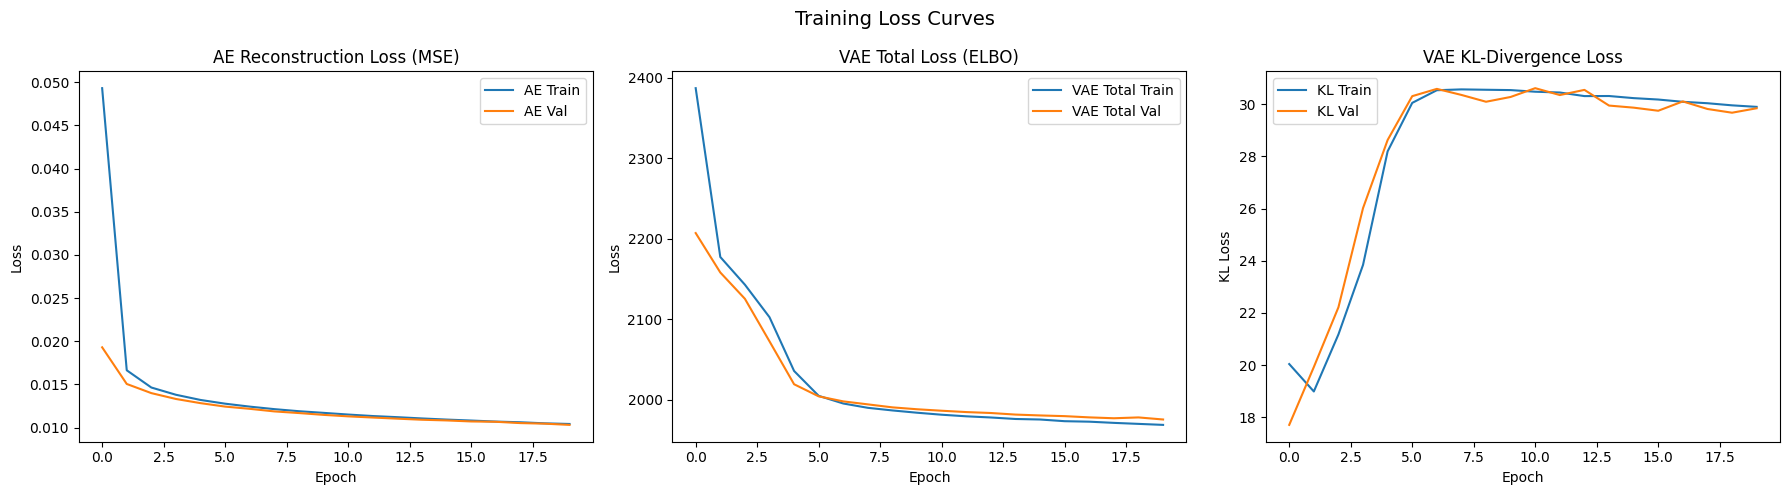

In [ ]:
"""
visualisation/loss_curves.py
Plot training and validation loss curves for both AE and VAE.
Style follows source 1 (plt.plot with legend).
"""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Loss Curves", fontsize=14)

# ── AE (full latent) ─────────────────────────────────────────────
ax = axes[0]
ax.plot(hist_ae_full.history["loss"],     label="AE Train")
ax.plot(hist_ae_full.history["val_loss"], label="AE Val")
ax.set_title("AE Reconstruction Loss (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# ── VAE total loss ────────────────────────────────────────────────
ax = axes[1]
ax.plot(hist_vae_full["loss"],     label="VAE Total Train")
ax.plot(hist_vae_full["val_loss"], label="VAE Total Val")
ax.set_title("VAE Total Loss (ELBO)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# ── VAE KL divergence ─────────────────────────────────────────────
ax = axes[2]
ax.plot(hist_vae_full["kl_loss"],     label="KL Train")
ax.plot(hist_vae_full["val_kl_loss"], label="KL Val")
ax.set_title("VAE KL-Divergence Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("KL Loss")
ax.legend()

plt.tight_layout()
plt.show()

---
## Section 6 — Reconstruction Analysis

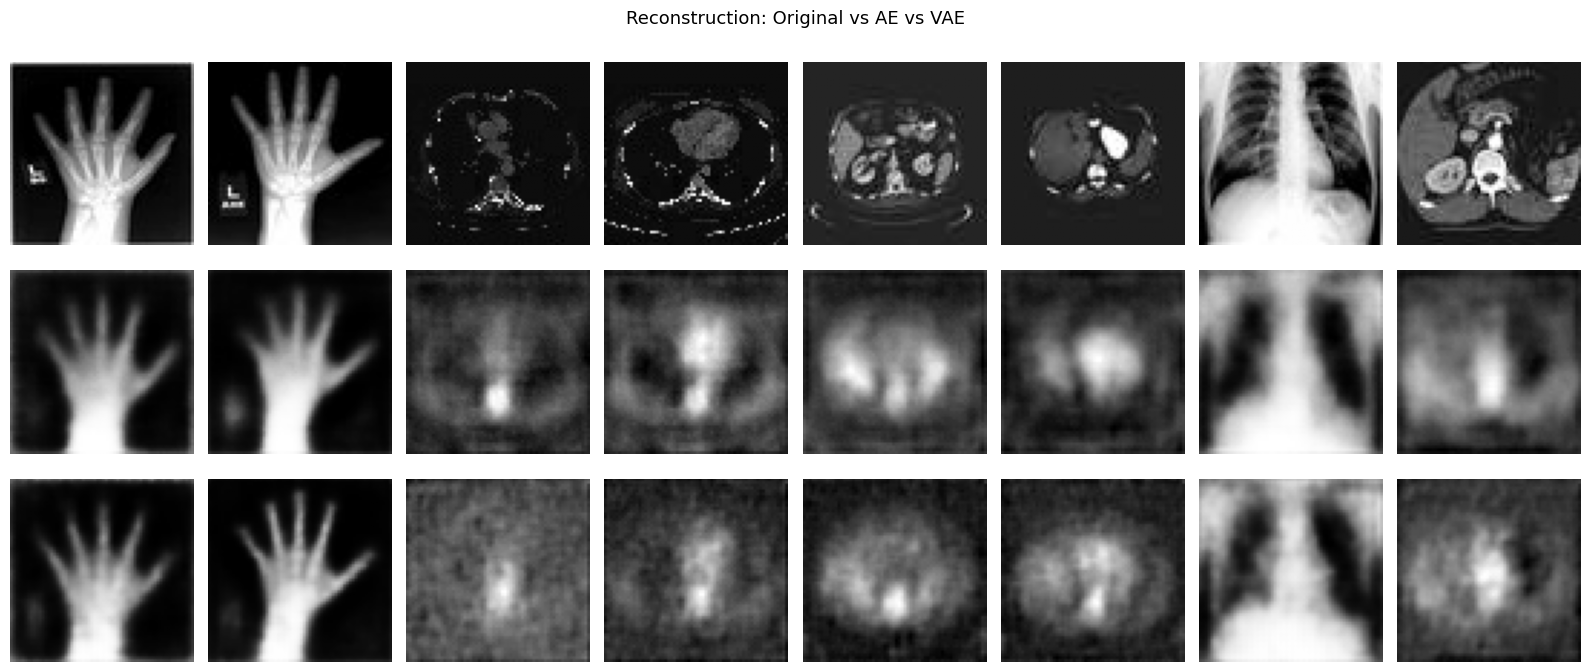

Average AE  reconstruction loss (MSE) on test set: 0.010135
Average VAE reconstruction loss (MSE) on test set: 0.010065


In [ ]:
"""
visualisation/reconstruction.py
Display grid: original | AE reconstruction | VAE reconstruction.
Grid style from source 1.
"""

N_SHOW: int = 8  # number of examples in the grid

# Get a test batch
test_batch = next(iter(test_ds))
originals  = test_batch[:N_SHOW]

# Encode → decode with AE (full latent)
ae_encoded = ae_full.encoder(originals).numpy()
ae_recons  = ae_full.decoder(ae_encoded).numpy()  # source 1

# Encode → reparameterise → decode with VAE (full latent)
vae_mean, vae_logvar = vae_full.encode(originals)
vae_z      = vae_full.reparameterize(vae_mean, vae_logvar)
vae_recons = vae_full.decode(vae_z, apply_sigmoid=True).numpy()  # source 2

# Plot three rows: original | AE | VAE
fig, axes = plt.subplots(3, N_SHOW, figsize=(N_SHOW * 2, 7))
fig.suptitle("Reconstruction: Original vs AE vs VAE", fontsize=13)

row_labels = ["Original", "AE", "VAE"]
images_rows = [originals.numpy(), ae_recons, vae_recons]

for row_idx, (row_label, row_imgs) in enumerate(zip(row_labels, images_rows)):
    for col_idx in range(N_SHOW):
        ax = axes[row_idx, col_idx]
        ax.imshow(row_imgs[col_idx].squeeze(), cmap="gray")
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=11)

plt.tight_layout()
plt.show()

# ── Average reconstruction loss on test set ──────────────────────
ae_test_losses  = []
vae_test_losses = []

mse = losses.MeanSquaredError()

for batch in test_ds:
    ae_out  = ae_full(batch)
    vae_out = vae_full(batch)          # uses call() → apply_sigmoid=True
    ae_test_losses.append(mse(batch, ae_out).numpy())
    vae_test_losses.append(mse(batch, vae_out).numpy())

print(f"Average AE  reconstruction loss (MSE) on test set: {np.mean(ae_test_losses):.6f}")
print(f"Average VAE reconstruction loss (MSE) on test set: {np.mean(vae_test_losses):.6f}")

---
## Section 7 — Latent Space Visualization

/tmp/ipykernel_2529/2739406694.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


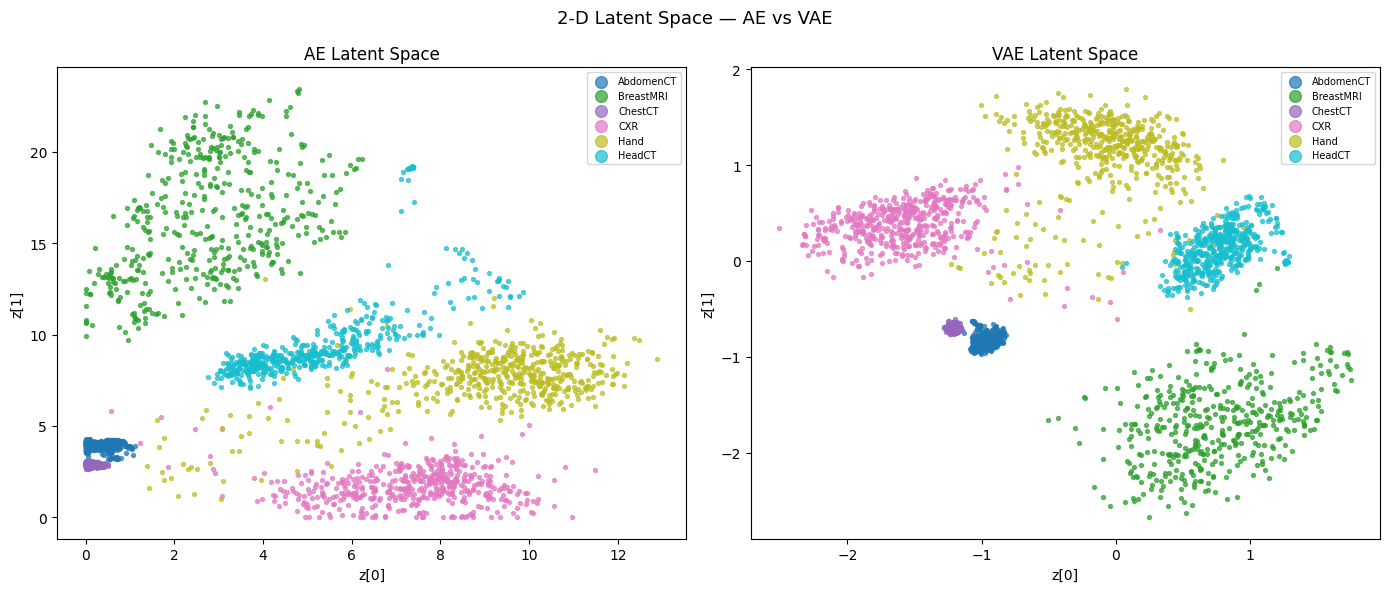

In [ ]:
"""
visualisation/latent_space.py
2-D latent scatter plots for AE and VAE coloured by class label.
Style follows source 2 (latent space visualisation).
"""

SCATTER_LIMIT: int = 3000   # max points for readability

ae_z_all,  ae_labels_all  = [], []
vae_z_all, vae_labels_all = [], []

for imgs, lbls in label_ds:
    # AE: deterministic encoding
    ae_z = ae_2d.encoder(imgs).numpy()
    ae_z_all.append(ae_z)
    ae_labels_all.append(lbls.numpy())

    # VAE: encode → z_mean (no sampling for cleaner visualisation)
    vae_mean, _ = vae_2d.encode(imgs)
    vae_z_all.append(vae_mean.numpy())
    vae_labels_all.append(lbls.numpy())

ae_z_all  = np.concatenate(ae_z_all,  axis=0)[:SCATTER_LIMIT]
ae_lbl    = np.concatenate(ae_labels_all, axis=0)[:SCATTER_LIMIT]
vae_z_all = np.concatenate(vae_z_all, axis=0)[:SCATTER_LIMIT]
vae_lbl   = np.concatenate(vae_labels_all, axis=0)[:SCATTER_LIMIT]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("2-D Latent Space — AE vs VAE", fontsize=13)

cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)

for cls in range(NUM_CLASSES):
    mask_ae  = ae_lbl  == cls
    mask_vae = vae_lbl == cls
    ax1.scatter(ae_z_all[mask_ae,  0], ae_z_all[mask_ae,  1],
                c=[cmap(cls)], label=CLASS_NAMES[cls], s=8, alpha=0.7)
    ax2.scatter(vae_z_all[mask_vae, 0], vae_z_all[mask_vae, 1],
                c=[cmap(cls)], label=CLASS_NAMES[cls], s=8, alpha=0.7)

ax1.set_title("AE Latent Space");  ax1.legend(markerscale=3, fontsize=7)
ax2.set_title("VAE Latent Space"); ax2.legend(markerscale=3, fontsize=7)

for ax in (ax1, ax2):
    ax.set_xlabel("z[0]"); ax.set_ylabel("z[1]")

plt.tight_layout()
plt.show()

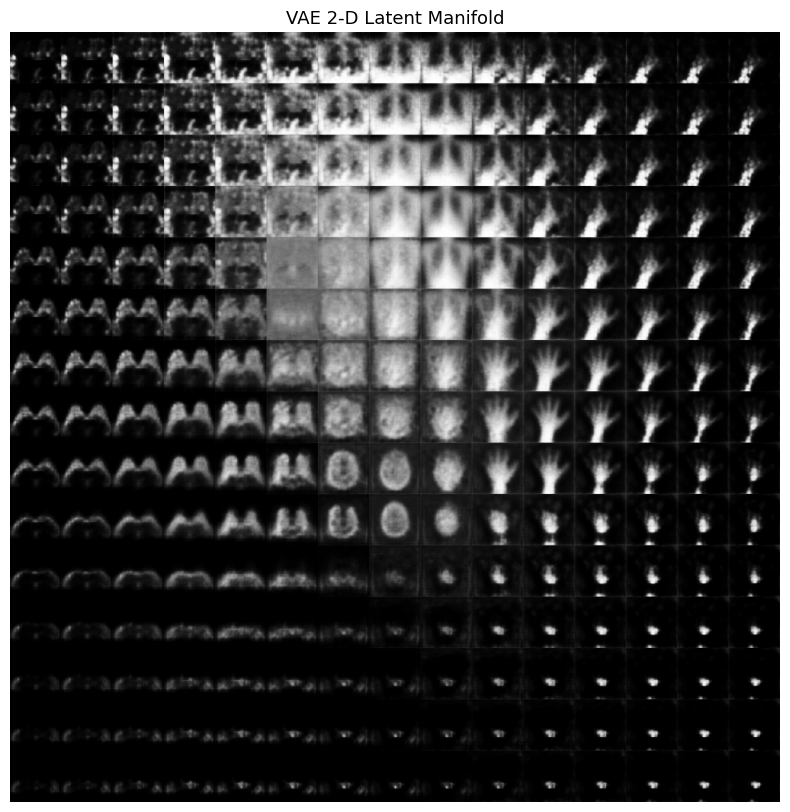

In [ ]:
"""
visualisation/latent_manifold.py
Decode a grid of (z0, z1) points from the 2-D VAE latent space.
Directly adapted from source 2: plot_latent_images().
"""


def plot_latent_manifold(
    model:      VAE,
    n:          int = MANIFOLD_N,
    img_size:   int = IMG_SIZE,
) -> None:
    """
    Plot n×n decoded images sampled on a uniform grid in 2-D latent space.
    Adapted from source 2 (plot_latent_images).

    Args:
        model:    Trained 2-D VAE.
        n:        Grid resolution.
        img_size: Side length of each image.
    """
    # Source 2 uses Normal quantiles for a perceptually uniform grid
    grid_x = np.linspace(-3, 3, n)   # simplified: linear grid
    grid_y = np.linspace(-3, 3, n)

    canvas_h = img_size * n
    canvas_w = img_size * n
    canvas   = np.zeros((canvas_h, canvas_w))

    for i, xi in enumerate(grid_x):
        for j, yj in enumerate(grid_y):
            z       = np.array([[xi, yj]], dtype=np.float32)
            decoded = model.sample(z)               # source 2
            img     = tf.reshape(decoded[0], (img_size, img_size)).numpy()
            canvas[
                i * img_size: (i + 1) * img_size,
                j * img_size: (j + 1) * img_size
            ] = img

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap="gray")
    plt.title("VAE 2-D Latent Manifold", fontsize=13)
    plt.axis("off")
    plt.show()


plot_latent_manifold(vae_2d, n=MANIFOLD_N)

---
## Section 8 — Sample Generation (VAE)

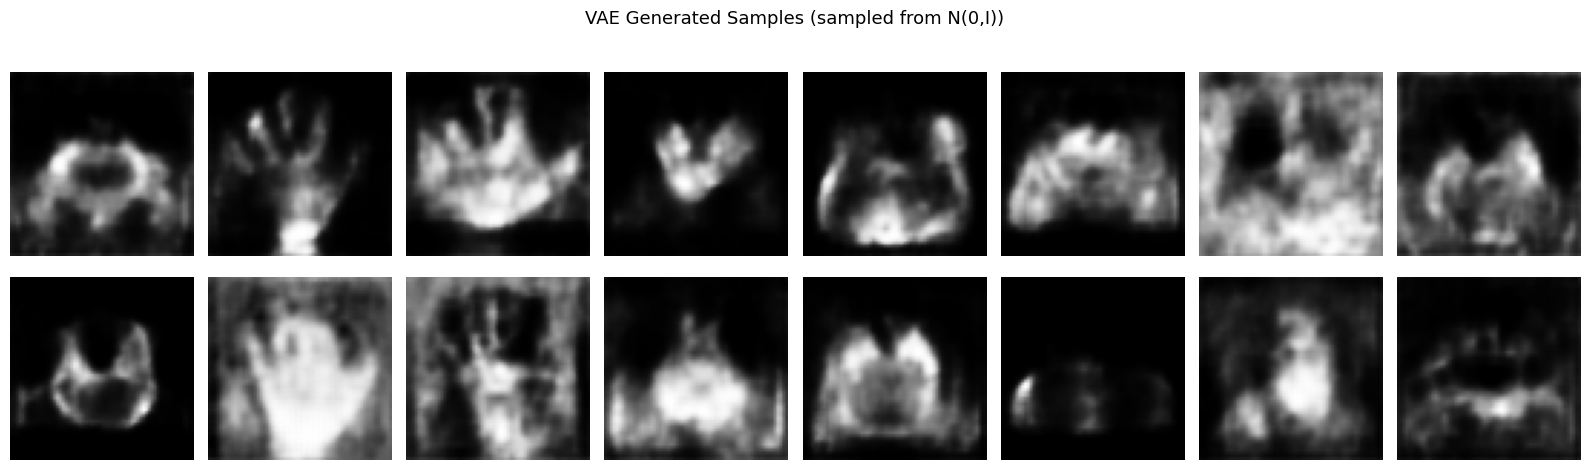

In [ ]:
"""
visualisation/generation.py
Generate images by sampling from N(0, I) and decoding.
Uses VAE.sample() exactly as in source 2.
"""

# ── Random samples from prior ─────────────────────────────────────
random_eps    = tf.random.normal(shape=(NUM_GENERATE, LATENT_DIM_FULL))
generated     = vae_full.sample(random_eps).numpy()   # source 2

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("VAE Generated Samples (sampled from N(0,I))", fontsize=13)
for ax, img in zip(axes.flat, generated):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

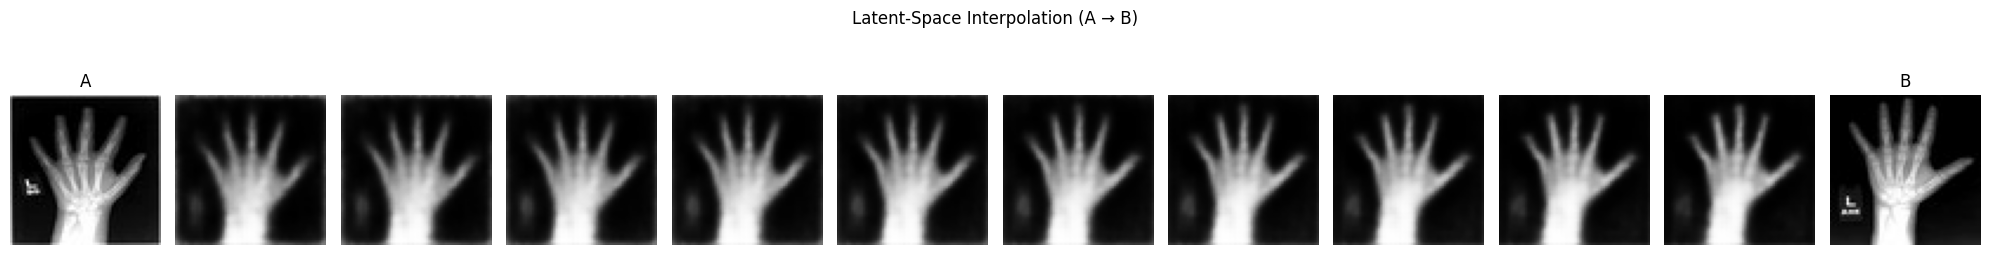

In [ ]:
"""
visualisation/interpolation.py
Linear interpolation between two latent points in the VAE 2-D space.
"""

N_STEPS: int = 10

# Pick two real test images and encode them
test_batch_2 = next(iter(test_ds))
img_a = test_batch_2[0:1]   # first image
img_b = test_batch_2[1:2]   # second image

mean_a, _ = vae_full.encode(img_a)
mean_b, _ = vae_full.encode(img_b)

alphas    = np.linspace(0.0, 1.0, N_STEPS)
interp_z  = np.array(
    [(1 - a) * mean_a.numpy()[0] + a * mean_b.numpy()[0] for a in alphas],
    dtype=np.float32
)   # shape (N_STEPS, latent_dim)

interp_imgs = vae_full.decode(
    tf.constant(interp_z), apply_sigmoid=True
).numpy()  # source 2

fig, axes = plt.subplots(1, N_STEPS + 2, figsize=(N_STEPS * 2, 3))
fig.suptitle("Latent-Space Interpolation (A → B)", fontsize=12)

axes[0].imshow(img_a.numpy()[0].squeeze(), cmap="gray")
axes[0].set_title("A"); axes[0].axis("off")

for i, img in enumerate(interp_imgs):
    axes[i + 1].imshow(img.squeeze(), cmap="gray")
    axes[i + 1].axis("off")

axes[-1].imshow(img_b.numpy()[0].squeeze(), cmap="gray")
axes[-1].set_title("B"); axes[-1].axis("off")

plt.tight_layout()
plt.show()

---
## Section 9 — Denoising

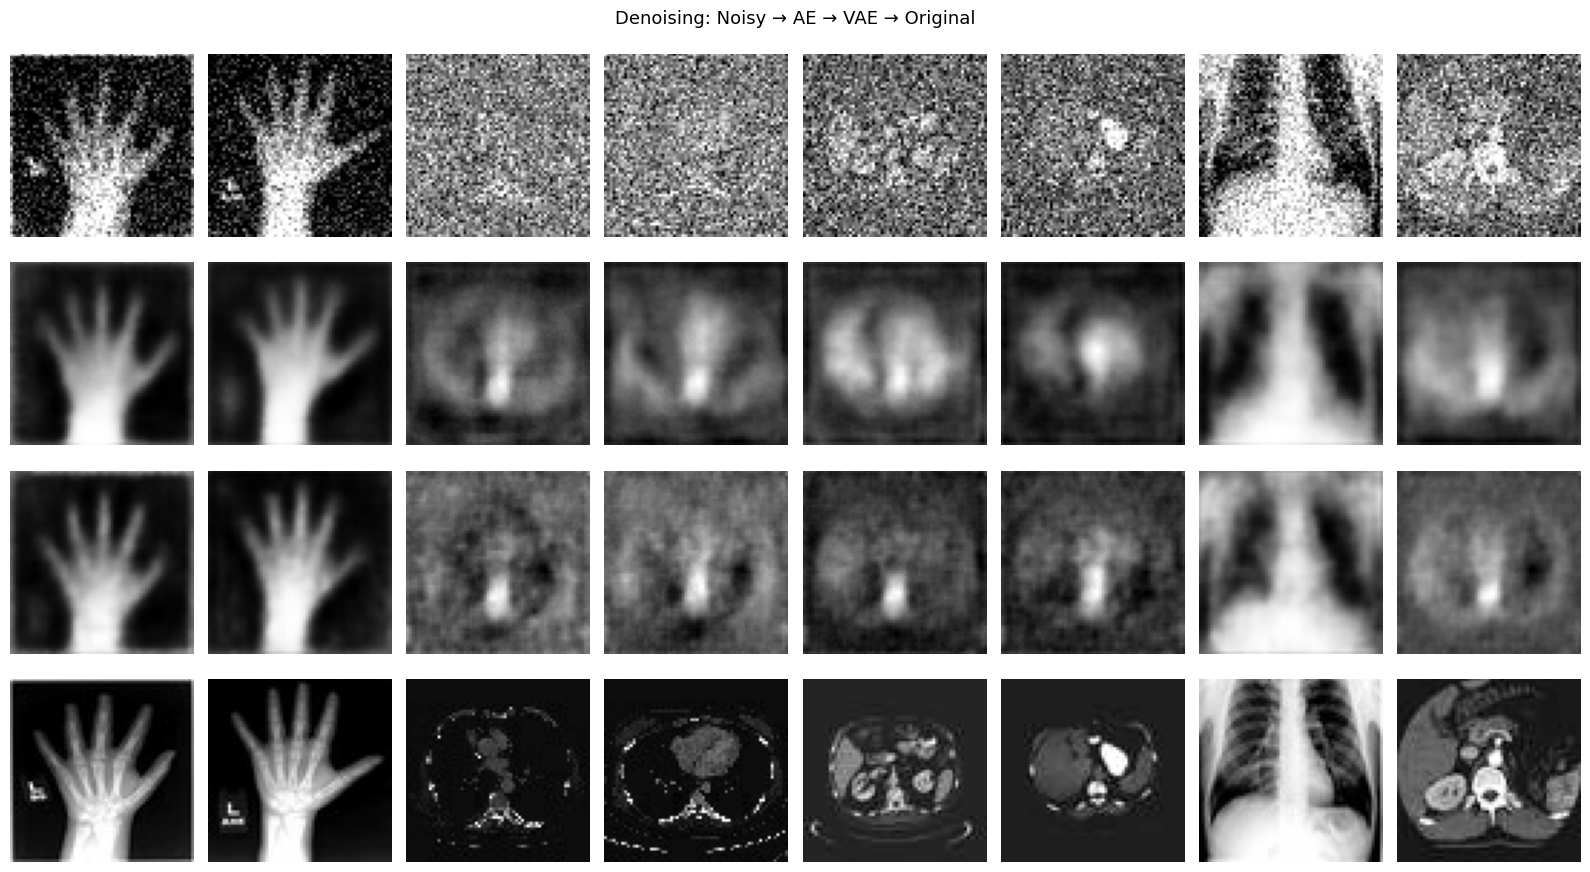

In [ ]:
"""
visualisation/denoising.py
Add Gaussian noise (source 1) and compare AE vs VAE denoising.
Display grid: Noisy | AE output | VAE output | Original.
"""

N_DENOISE: int = 8

clean_batch = next(iter(test_ds))[:N_DENOISE]

# source 1: add noise and clip
noisy_batch = clean_batch + NOISE_FACTOR * tf.random.normal(
    shape=clean_batch.shape
)
noisy_batch = tf.clip_by_value(noisy_batch, 0.0, 1.0)  # source 1

# Denoise with AE
ae_denoised = ae_full(noisy_batch).numpy()

# Denoise with VAE
vae_denoised = vae_full(noisy_batch).numpy()

# Plot: Noisy | AE | VAE | Original
fig, axes = plt.subplots(4, N_DENOISE, figsize=(N_DENOISE * 2, 9))
fig.suptitle("Denoising: Noisy → AE → VAE → Original", fontsize=13)

row_labels = ["Noisy Input", "AE Denoised", "VAE Denoised", "Original"]
row_imgs   = [
    noisy_batch.numpy(),
    ae_denoised,
    vae_denoised,
    clean_batch.numpy(),
]

for r, (lbl, imgs) in enumerate(zip(row_labels, row_imgs)):
    for c in range(N_DENOISE):
        ax = axes[r, c]
        ax.imshow(imgs[c].squeeze(), cmap="gray")
        ax.axis("off")
    axes[r, 0].set_ylabel(lbl, fontsize=10)

plt.tight_layout()
plt.show()